# DSPG — Distribution-based Structural Policy Gradient

Notebook for the **general-equilibrium (GE) Huggett economy** with bond-market clearing (same qualitative setup as in the DSPG paper). Figures are saved under **`figures_tables/`** when you run plotting cells — keep the working directory at the **repository root** so paths resolve.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
# Use double precision, important for stability, yet slower
# We may not use this when training the neural networks if it is costly
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import haiku as hk 
import optax
import matplotlib.pyplot as plt
import time
import numpy as np
from scipy.stats import gaussian_kde
colors = [
    "royalblue", "green", "orange", "red", "navy", "brown", "teal", "pink", "gray"
]

def set_static_styles():
    plt.rcParams.update({
        'axes.titlesize': 20,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'lines.linewidth': 3,
        'lines.markersize': 6,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Palatino', 'Charter', 'serif']
    })

def create_subplots(nrow=1,ncol=1,sharex=False,sharey=False):
    set_static_styles()
    width, height = 7*ncol, 5*nrow
    fig, axs = plt.subplots(nrow, ncol, figsize=(width, height),sharex=sharex,sharey=sharey)
    if nrow*ncol == 1:
        axs = [[axs]]
    elif nrow == 1:
        axs = [axs]
    elif ncol == 1:
        axs = [[ax] for ax in axs]
    return fig, axs

## Step 1 — Economy (GE Huggett)

Define grids and transitions for productivity, assets, TFP \(z\), bond supply \(B\), and finite-horizon truncation — aligned with `dspg/ablation_study.py`.


In [2]:
seed = 0
key = jax.random.PRNGKey(seed)
# wealth grid
na = 200 # number of asset grid points
a_min = 0.0 # minimum asset level (borrowing limit)
a_max = 150.0 # maximum asset level
a_grid = jnp.geomspace(0.25,a_max-a_min,na) + a_min - 0.25 # asset grid
# income process
ne = 3 # number of income states
e_grid = jnp.asarray([0.5488, 1.000, 1.8221]) # income states
e_trans = jnp.asarray(
    [[0.6460, 0.3539, 0.0001],
    [0.0304, 0.9392, 0.0304],
    [0.0001, 0.3539, 0.6460]]) # income transition matrix
# compute the stationary distribution of income
A = jnp.transpose(e_trans) - jnp.eye(ne)
A = jnp.vstack([A, jnp.ones(ne)])
b = jnp.zeros(ne + 1)
b = b.at[-1].set(1.0)
e_dist_stationary = jnp.linalg.lstsq(A, b, rcond=None)[0]
e_mean = jnp.sum(e_dist_stationary * e_grid)
e_grid = e_grid / e_mean # normalize mean income to 1
a_dist = jnp.repeat(a_grid, ne).reshape(na,ne) # initial wealth distribution
e_dist = jnp.tile(e_grid, na).reshape(na,ne) # initial income distribution
# TFP shock process
nz = 5 # number of TFP states
z_grid = jnp.asarray([0.9139, 0.9560, 1.0000, 1.0460, 1.0942]) # TFP states
z_trans = jnp.asarray(
    [[0.8478, 0.1522, 0.0000, 0.0000, 0.0000],
    [0.0195, 0.8962, 0.0843, 0.0000, 0.0000],
    [0.0000, 0.0427, 0.9147, 0.0427, 0.0000],
    [0.0000, 0.0000, 0.0843, 0.8962, 0.0195],
    [0.0000, 0.0000, 0.0000, 0.1522, 0.8478]]) # TFP transition matrix
# model parameters
beta = 0.975 # discount factor
sigma = 1 # relative risk aversion
trunc_eps = 1e-2 # truncation error for infinite horizon problem
min_c = 1e-3 # minimum consumption to avoid numerical issues
B = 5 # total bond supply
T = jnp.floor(jnp.log(trunc_eps) / jnp.log(beta)).astype(int) # time horizon for finite horizon problem
@jax.jit
def utility(c,sigma):
    return jax.lax.cond(
        sigma == 1.0,
        lambda : jnp.log(c),
        lambda : c**(1.0 - sigma) / (1.0 - sigma)
    )

**Bond clearing for the equilibrium interest rate** when there is no aggregate risk on TFP in this block (fixed \(z = 1\)).


In [27]:
@jax.jit
def iterpolate_nonuniform(x, grids):
    # make x within the grid range
    x = jnp.clip(x, grids[0], grids[-1])
    idx = jnp.searchsorted(grids, x) - 1
    idx = jnp.clip(idx, 0, len(grids)-2)
    x0, x1 = grids[idx], grids[idx+1]
    y0, y1 = idx.astype(int), (idx+1).astype(int)
    w0 = (x1 - x) / (x1 - x0 + 1e-12)
    w1 = 1.0 - w0
    return y0, y1, w0, w1

@jax.jit
def update_V(aidx,V,r):
    def loop_e(eidx):
        a, e = a_grid[aidx], e_grid[eidx]
        wealth = (1+r)*a + e
        def find_all_v(c):
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            expected_future_V = jnp.sum((V[y0]*w0 + V[y1]*w1)*e_trans[eidx])
            return utility(c,sigma) + beta * expected_future_V
        cgrid = jnp.linspace(1e-3, wealth - a_min, 8192)
        expected_Vs = jax.vmap(find_all_v)(cgrid)
        expected_V = jnp.max(expected_Vs)
        opt_c = cgrid[jnp.argmax(expected_Vs)]
        return expected_V, opt_c
    return jax.vmap(loop_e)(jnp.arange(ne))

def vfi(r):
    V = jnp.zeros((na,ne))
    while True:
        V_new,opt_c = jax.vmap(update_V,in_axes=(0,None,None))(jnp.arange(na),V,r)
        if jnp.max(jnp.abs(V_new - V)) < 1e-8:
            break
        V = V_new
    return V, opt_c

@jax.jit
def state_transit(opt_c,g,r):
    def loop_a(aidx):
        def loop_e(eidx):
            a, e = a_grid[aidx], e_grid[eidx]
            wealth = (1+r)*a + e
            c = opt_c[aidx,eidx]
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            g_new = jnp.zeros((na,ne))
            g_new = g_new.at[y0].set(g[aidx,eidx]*w0*e_trans[eidx])
            g_new = g_new.at[y1].set(g[aidx,eidx]*w1*e_trans[eidx])
            return g_new
        return jax.vmap(loop_e)(jnp.arange(ne))
    return jax.vmap(loop_a)(jnp.arange(na)).sum(axis=(0,1))

@jax.jit
def compute_stationary_dis(opt_c,r):
    g = jnp.full((na,ne),1.0/(na*ne))
    def step(g,_):
        return state_transit(opt_c,g,r), g
    return jax.lax.scan(step,g,length=2000)


# outer loop: binary search for interest rate r
left, right = 0.0, 0.1
while left < right:
    mid = (left + right) / 2.0
    V,opt_c = vfi(mid)
    g,g_all = compute_stationary_dis(opt_c,mid)
    asset_supply_err = jnp.sum(g*a_dist) - B
    if asset_supply_err > 0.0:
        right = mid
    else:
        left = mid
    print(f"r: {mid:.6f}, asset supply err: {asset_supply_err:.3E}")
    if jnp.abs(asset_supply_err) < 1e-5:
        break
steady_r = mid
steady_dist = g
print(f"Equilibrium interest rate: {steady_r:.6f}")
print(f"Aggregate saving at equilibrium: {asset_supply_err + B:.3E}")

r: 0.050000, asset supply err: 1.447E+02
r: 0.025000, asset supply err: 4.316E+00
r: 0.012500, asset supply err: -4.514E+00
r: 0.018750, asset supply err: -4.037E+00
r: 0.021875, asset supply err: -3.386E+00
r: 0.023438, asset supply err: -2.533E+00
r: 0.024219, asset supply err: -1.544E+00
r: 0.024609, asset supply err: -4.640E-01
r: 0.024805, asset supply err: 9.258E-01
r: 0.024707, asset supply err: 7.674E-02
r: 0.024658, asset supply err: -2.132E-01
r: 0.024683, asset supply err: -7.848E-02
r: 0.024695, asset supply err: -1.929E-03
r: 0.024701, asset supply err: 3.998E-02
r: 0.024698, asset supply err: 1.556E-02
r: 0.024696, asset supply err: 4.866E-03
r: 0.024696, asset supply err: 2.491E-03
r: 0.024695, asset supply err: -6.106E-04
r: 0.024695, asset supply err: 8.777E-05
r: 0.024695, asset supply err: -9.780E-05
r: 0.024695, asset supply err: -5.022E-06
Equilibrium interest rate: 0.024695
Aggregate saving at equilibrium: 5.000E+00


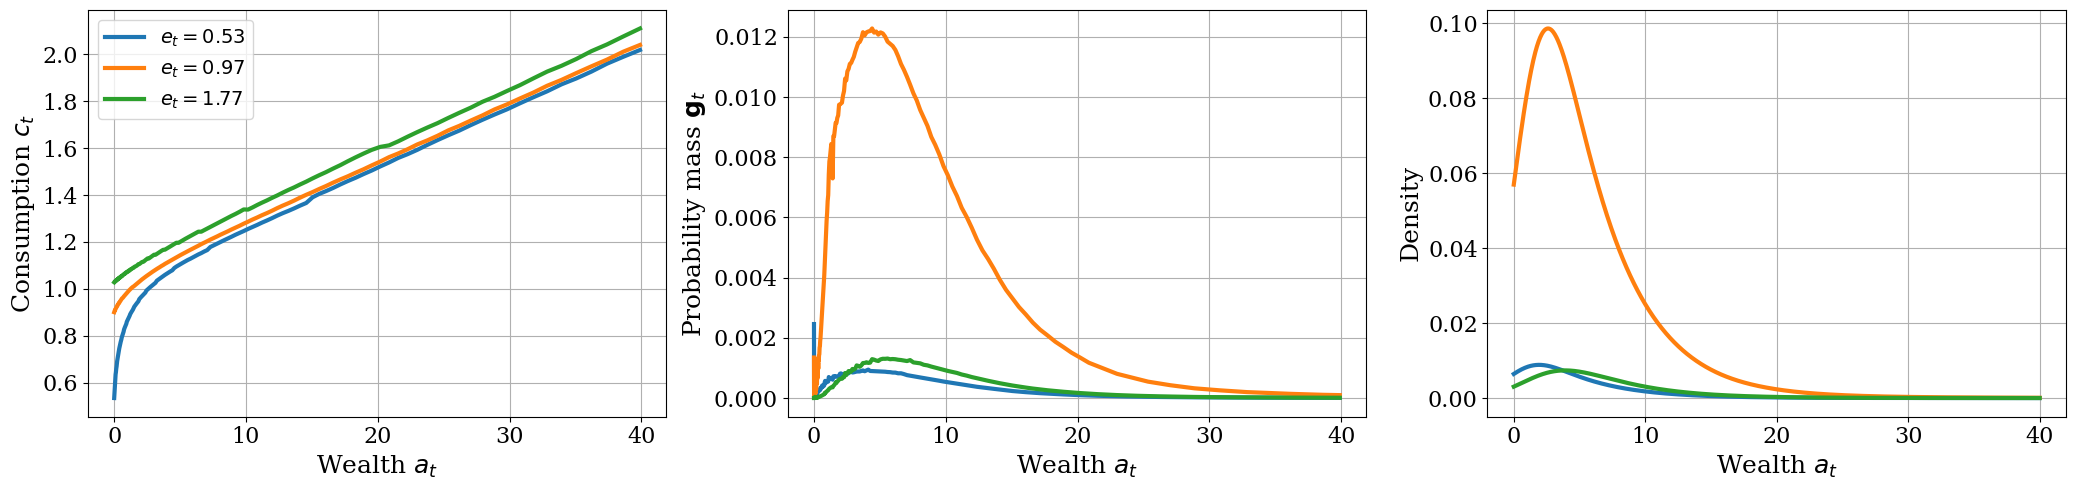

In [28]:
fig,axs = create_subplots(1,3)
# Figure 1: Optimal policy function
ax = axs[0][0]
max_plot_a = 40.0
idxx = jnp.where(a_grid<=max_plot_a)[0]
for eidx in range(ne):
    ax.plot(a_grid[idxx], opt_c[:,eidx][idxx], label=f"$e_t={e_grid[eidx]:.2f}$")
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Consumption $c_t$")
ax.legend()
ax.grid(True)
# Figure 2: Stationary wealth distribution
ax = axs[0][1]
for eidx in range(ne):
    # plot original points
    ax.plot(a_grid[idxx], g[idxx,eidx], label=f'ORG: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Probability mass $\mathbf{g}_t$")
#ax.legend()
ax.grid(True)
# Figure 3: Stationary wealth distribution KDE estimate
ax = axs[0][2]
for eidx in range(ne):
    kde = gaussian_kde(a_grid, weights=g[:,eidx])
    x_smooth = np.linspace(a_min, max_plot_a, 1000)
    y_smooth = kde(x_smooth) * g[:,eidx].sum()
    ax.plot(x_smooth, y_smooth, label=f'KDE: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Density")
#ax.legend()
ax.grid(True)

fig.tight_layout()
fig.savefig("./figures_tables/steady_state_results.pdf")

## Step 2 — Policy network

Build the Haiku U-Net that maps the cross-sectional distribution \(\mathbf g\) and prices to consumption shares.


$$
\texttt{U-Net}(\mathbf{g},r) = \mathbf{c}_{\texttt{share}}(z)
$$

The U-Net returns **consumption-share parameters** by productivity state \(z\); with bond market clearing, the interest rate \(r\) is consistent with total bond supply.


In [29]:
activation = jax.nn.leaky_relu
pool = hk.AvgPool
# consumption bounds: c in [min_c, max_csmp]
# max_csmp: maximum consumption given borrowing limit a_min and not greater than 2*opt_c
diffs = jnp.diff(opt_c,axis=0)
max_diff = jnp.zeros((na,ne))
max_diff = max_diff.at[0,:].set(diffs[0,:])
max_diff = max_diff.at[1:,:].set(diffs)
max_diff *= 2.0
csmp0 = opt_c[0,:] - jnp.asarray([0.05,0.02,0.1])

class DoubleConv(hk.Module):
    def __init__(self, out_channels, name=None):
        super().__init__(name=name)
        self.out_channels = out_channels

    def __call__(self, x):
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding='SAME')(x)
        x = activation(x)
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding='SAME')(x)
        x = activation(x)
        return x
    
def forward_fn(g):
    # g: (B, na, ne), r: (B,) -> c: (B, na, ne)
    # normalize the input
    g = g / jnp.sum(g, axis=(1,2), keepdims=True)
    g = g * na * ne
    # Layer 1: from (B, na, ne) to (B, na, 8)
    x1 = DoubleConv(4)(g)
    # Layer 2: from (B, na, 8) to (B, na//2, 16)
    x2 = pool(window_shape=2, strides=2, padding='SAME')(x1)
    x2 = DoubleConv(4)(x2)
    # Layer 3: from (B, na//2, 16) to (B, na//4, 32)
    x3 = pool(window_shape=2, strides=2, padding='SAME')(x2)
    x3 = DoubleConv(4)(x3)
    # layer 4: from (B, na//4, 32) to (B, na//8, 64)
    #x4 = pool(window_shape=2, strides=2, padding='SAME')(x3)
    #x4 = DoubleConv(32)(x4)

    y = x3
    # Layer 5: from (B, na//8, 64) to (B, na//4, 32)
    #y = hk.Conv1DTranspose(output_channels=32, kernel_shape=3, stride=2, padding='SAME')(x4)
    #y = y[:, :x3.shape[1], :]  # crop if needed
    #y = jnp.concatenate([y, x3], axis=-1)
    #y = DoubleConv(32)(y)
    # Layer 6: from (B, na//4, 32) to (B, na//2, 16)
    y = hk.Conv1DTranspose(output_channels=4, kernel_shape=3, stride=2, padding='SAME')(y)
    y = y[:, :x2.shape[1], :]  # crop if needed
    y = jnp.concatenate([y, x2], axis=-1)
    y = DoubleConv(4)(y)
    # Layer 7: from (B, na//2, 16) to (B, na, 8)
    y = hk.Conv1DTranspose(output_channels=4, kernel_shape=3, stride=2, padding='SAME')(y)
    y = y[:, :x1.shape[1], :]  # crop if needed
    y = jnp.concatenate([y, x1], axis=-1)
    y = DoubleConv(4)(y)
    # Final layer: from (B, na, 8) to (B, na, ne*nz)
    y = hk.Conv1D(output_channels=ne*nz, kernel_shape=1, stride=1, padding='SAME')(y)
    #y = hk.Linear(ne*nz)(y)
    y = jax.nn.sigmoid(y.reshape(y.shape[0], na, ne, nz))
    # output consumption: c in [min_c, max_csmp]
    c = jnp.zeros((y.shape[0], na+1, ne, nz))
    c = c.at[:,0,:,:].set(
        csmp0[None,:,None] * jnp.ones((y.shape[0],ne,nz))
    )
    c = c.at[:,1:,:,:].set(
        y * max_diff[None,...,None]
    )
    c = jnp.cumsum(c, axis=1)
    c = c[:,1:,:,:]
    return c

forward = hk.without_apply_rng(hk.transform(forward_fn))
# initialize model parameters
_key,key = jax.random.split(key)
dummy_g = jnp.ones((2, na, ne))
_key,key = jax.random.split(key)
params = forward.init(_key, dummy_g)
# test
forward.apply(params, dummy_g)[0,...,0]

Array([[0.49260566, 0.88213971, 0.92939199],
       [0.50096576, 0.88388689, 0.93076574],
       [0.5096193 , 0.88553993, 0.93072906],
       [0.51854731, 0.8863675 , 0.93080546],
       [0.52777001, 0.88707986, 0.93188307],
       [0.53729427, 0.88903705, 0.93219927],
       [0.54712927, 0.8906449 , 0.93219028],
       [0.55728596, 0.89062639, 0.93207665],
       [0.56777402, 0.89212475, 0.93366667],
       [0.57860517, 0.89363498, 0.93380638],
       [0.58701697, 0.89541601, 0.93384388],
       [0.59310475, 0.89589141, 0.93562032],
       [0.59665087, 0.89728175, 0.9356928 ],
       [0.60246962, 0.89894024, 0.93566203],
       [0.6106007 , 0.90073642, 0.93693486],
       [0.61711283, 0.9023955 , 0.93693796],
       [0.62138417, 0.90237289, 0.9370733 ],
       [0.6273173 , 0.90399485, 0.93974167],
       [0.63599047, 0.90603024, 0.93968426],
       [0.64481785, 0.90776555, 0.93976057],
       [0.65043603, 0.90947802, 0.94119918],
       [0.65587568, 0.91116154, 0.94106562],
       [0.

## Step 3 — Train DSPG in the dynamic environment

Simulate Markov TFP, roll the cross-section forward, and run the notebook’s DSPG training / evaluation (see code for learning rates and batch size).


In [30]:
batch_size = 512
epoch = 200
train_lr = optax.exponential_decay(2e-3,epoch,0.5)
optimizer = optax.adam(train_lr)
opt_state = optimizer.init(params)

In [31]:
@jax.jit
def update_g(wealth_next_batch,g_batch):
    def loop_B(wealth_next,g):
        def loop_a(aidx):
            def loop_e(eidx):
                next_a = wealth_next[aidx,eidx]
                y0, y1, w0, w1 = iterpolate_nonuniform(next_a, a_grid)
                g_new = jnp.zeros((na,ne))
                enext_prob = e_trans[eidx]
                g_new = g_new.at[y0].set(g[aidx,eidx]*w0*enext_prob)
                g_new = g_new.at[y1].set(g[aidx,eidx]*w1*enext_prob)
                return g_new
            return jax.vmap(loop_e)(jnp.arange(ne))
        return jax.vmap(loop_a)(jnp.arange(na))
    return jax.vmap(loop_B)(wealth_next_batch,g_batch).sum(axis=(1,2))

def cumulative_utility_loss(params,key,g):
    def step(pack,_):
        g_batch, zidx, discount, key = pack
        c_of_z = forward.apply(params, g_batch) # (B, na, ne, nz)
        def assign_c(idx,y):
            return y[...,idx]
        c = jax.vmap(assign_c)(zidx,c_of_z) # (B, na, ne)
        C = jnp.sum(c * g_batch, axis=(1,2)) # (B,)
        R = (B + C - z_grid[zidx]*jnp.sum(g_batch*e_dist[None,...],axis=(1,2))) / jnp.sum(g_batch*a_dist[None,...], axis=(1,2))  # (B,)
        r = R - 1
        # r = jnp.clip(r, 0.5 * steady_r, 1.5 * steady_r)
        r = jax.lax.stop_gradient(r)
        wealth = (1 + r[:,None,None]) * a_dist[None,...] + e_dist[None,...] * z_grid[zidx][:,None,None] # (B,na,ne)

        # update g
        c = jnp.minimum(c, wealth - a_min - min_c) # ensure feasibility
        wealth_next = wealth - c # (B,na,ne)
        g_batch = update_g(wealth_next,g_batch)
        util = jnp.sum(utility(c,sigma) * g_batch,axis=(1,2)) * discount # (B,)
        discount *= beta
        _key, key = jax.random.split(key)
        keys = jax.random.split(_key,batch_size)
        def update_z(idx,key):
            return jax.random.choice(key,nz,p=z_trans[idx])
        zidx = jax.vmap(update_z)(zidx,keys)
        return (g_batch, zidx, discount, key), util

    key,_key = jax.random.split(key)
    zidx = jax.random.choice(_key,nz,(batch_size,))
    discount = 1.0
    (final_g, _, _, _), utilities = jax.lax.scan(step, (g, zidx, discount, key), None, length=T)
    # utilities: (T,B)
    total_utility = jnp.sum(utilities,axis=0).mean() # ()
    return -total_utility, final_g

@jax.jit
def train_step_2(params, opt_state, key, g0):
    # g = jnp.ones((batch_size, na, ne)) / (na*ne)
    g = g0#jnp.ones((batch_size, na, ne)) * steady_dist[None,...]
    (loss,final_g), grads = jax.value_and_grad(cumulative_utility_loss,has_aux=True)(params,key,g)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    agg_saving = jnp.sum(final_g * a_dist[None,...], axis=(1,2))
    return params, opt_state, loss, agg_saving, final_g

tgts = []
st = time.time()
for ep in range(epoch):
    key,_key = jax.random.split(key)
    if ep<50:
        g0 = jnp.ones((batch_size, na, ne)) * steady_dist[None,...]
    else:
        g0 = final_g
    params, opt_state, loss, agg_saving, final_g = train_step_2(params, opt_state, _key, g0)
    tgts.append(-loss.item())
    print(f"Train Epoch {ep+1}, Target: {-loss:.6f}, Agg Saving Error: MAX-{jnp.max(jnp.abs(agg_saving-B)):.3E} AVG-{jnp.mean(jnp.abs(agg_saving-B)):.3E}")
et = time.time()
g_steady_nn = jnp.mean(final_g,0)
print(f"Training time: {et - st:.2f} seconds")

W0420 14:39:05.826784 2508961 hlo_rematerialization.cc:3198] Can't reduce memory use below 16.87GiB (18117206530 bytes) by rematerialization; only reduced to 16.97GiB (18219221352 bytes), down from 17.00GiB (18255276912 bytes) originally


Train Epoch 1, Target: 3.550592, Agg Saving Error: MAX-5.596E-05 AVG-5.743E-07
Train Epoch 2, Target: 3.606642, Agg Saving Error: MAX-4.014E-05 AVG-6.313E-07
Train Epoch 3, Target: 3.681046, Agg Saving Error: MAX-5.745E-05 AVG-9.479E-07
Train Epoch 4, Target: 3.758117, Agg Saving Error: MAX-3.394E-05 AVG-7.409E-07
Train Epoch 5, Target: 3.797024, Agg Saving Error: MAX-3.893E-05 AVG-4.673E-07
Train Epoch 6, Target: 3.875449, Agg Saving Error: MAX-4.053E-05 AVG-4.515E-07
Train Epoch 7, Target: 3.917514, Agg Saving Error: MAX-5.275E-05 AVG-6.492E-07
Train Epoch 8, Target: 4.012603, Agg Saving Error: MAX-2.270E-05 AVG-5.230E-07
Train Epoch 9, Target: 4.013066, Agg Saving Error: MAX-3.167E-05 AVG-3.958E-07
Train Epoch 10, Target: 4.082964, Agg Saving Error: MAX-3.085E-05 AVG-7.131E-07
Train Epoch 11, Target: 4.123198, Agg Saving Error: MAX-2.554E-05 AVG-3.957E-07
Train Epoch 12, Target: 4.175541, Agg Saving Error: MAX-2.329E-05 AVG-4.727E-07
Train Epoch 13, Target: 4.190040, Agg Saving Erro

In [32]:
def simulation(params,key):
    def step(pack,_):
        g_batch, zidx, discount, key = pack
        c_of_z = forward.apply(params, g_batch) # (B, na, ne, nz)
        z = z_grid[zidx]
        def assign_c(idx,y):
            return y[...,idx]
        c = jax.vmap(assign_c)(zidx,c_of_z) # (B, na, ne)
        C = jnp.sum(c * g_batch, axis=(1,2)) # (B,)
        R = (B + C - z_grid[zidx]) / jnp.sum(g_batch*a_dist[None,...], axis=(1,2))  # (B,)
        r = R - 1
        # r = jnp.clip(r, 0.5 * steady_r, 1.5 * steady_r)
        r = jax.lax.stop_gradient(r)
        wealth = (1 + r[:,None,None]) * a_dist[None,...] + e_dist[None,...] * z_grid[zidx][:,None,None] # (B,na,ne)
        c = jnp.minimum(c, wealth - a_min - min_c) # ensure feasibility
        wealth_next = wealth - c # (B,na,ne)
        g_batch = update_g(wealth_next,g_batch)
        discount *= beta
        _key, key = jax.random.split(key)
        keys = jax.random.split(_key,batch_size)
        def update_z(idx,key):
            return jax.random.choice(key,nz,p=z_trans[idx])
        zidx = jax.vmap(update_z)(zidx,keys)
        return (g_batch, zidx, discount, key), (r, jnp.sum(g_batch*a_dist[None,...],axis=(1,2)),c,z)

    key,_key = jax.random.split(key)
    zidx = jax.random.choice(_key,nz,(batch_size,))
    g_batch = jnp.ones((batch_size, na, ne)) * g_steady_nn[None,...]
    discount = 1.0
    (final_g, _, _, _), data = jax.lax.scan(step, (g_batch, zidx, discount, key), None, length=T+500)
    # remove first 500 burn-in steps
    data = jax.tree_util.tree_map(lambda x: x[500:,...], data)
    return data,final_g

In [33]:
# evaluate the final policy
key,_key = jax.random.split(key)
(r,b,c,z),final_g = simulation(params,_key)
final_g.shape,r.shape,b.shape,c.shape,z.shape

((512, 200, 3), (181, 512), (181, 512), (181, 512, 200, 3), (181, 512))

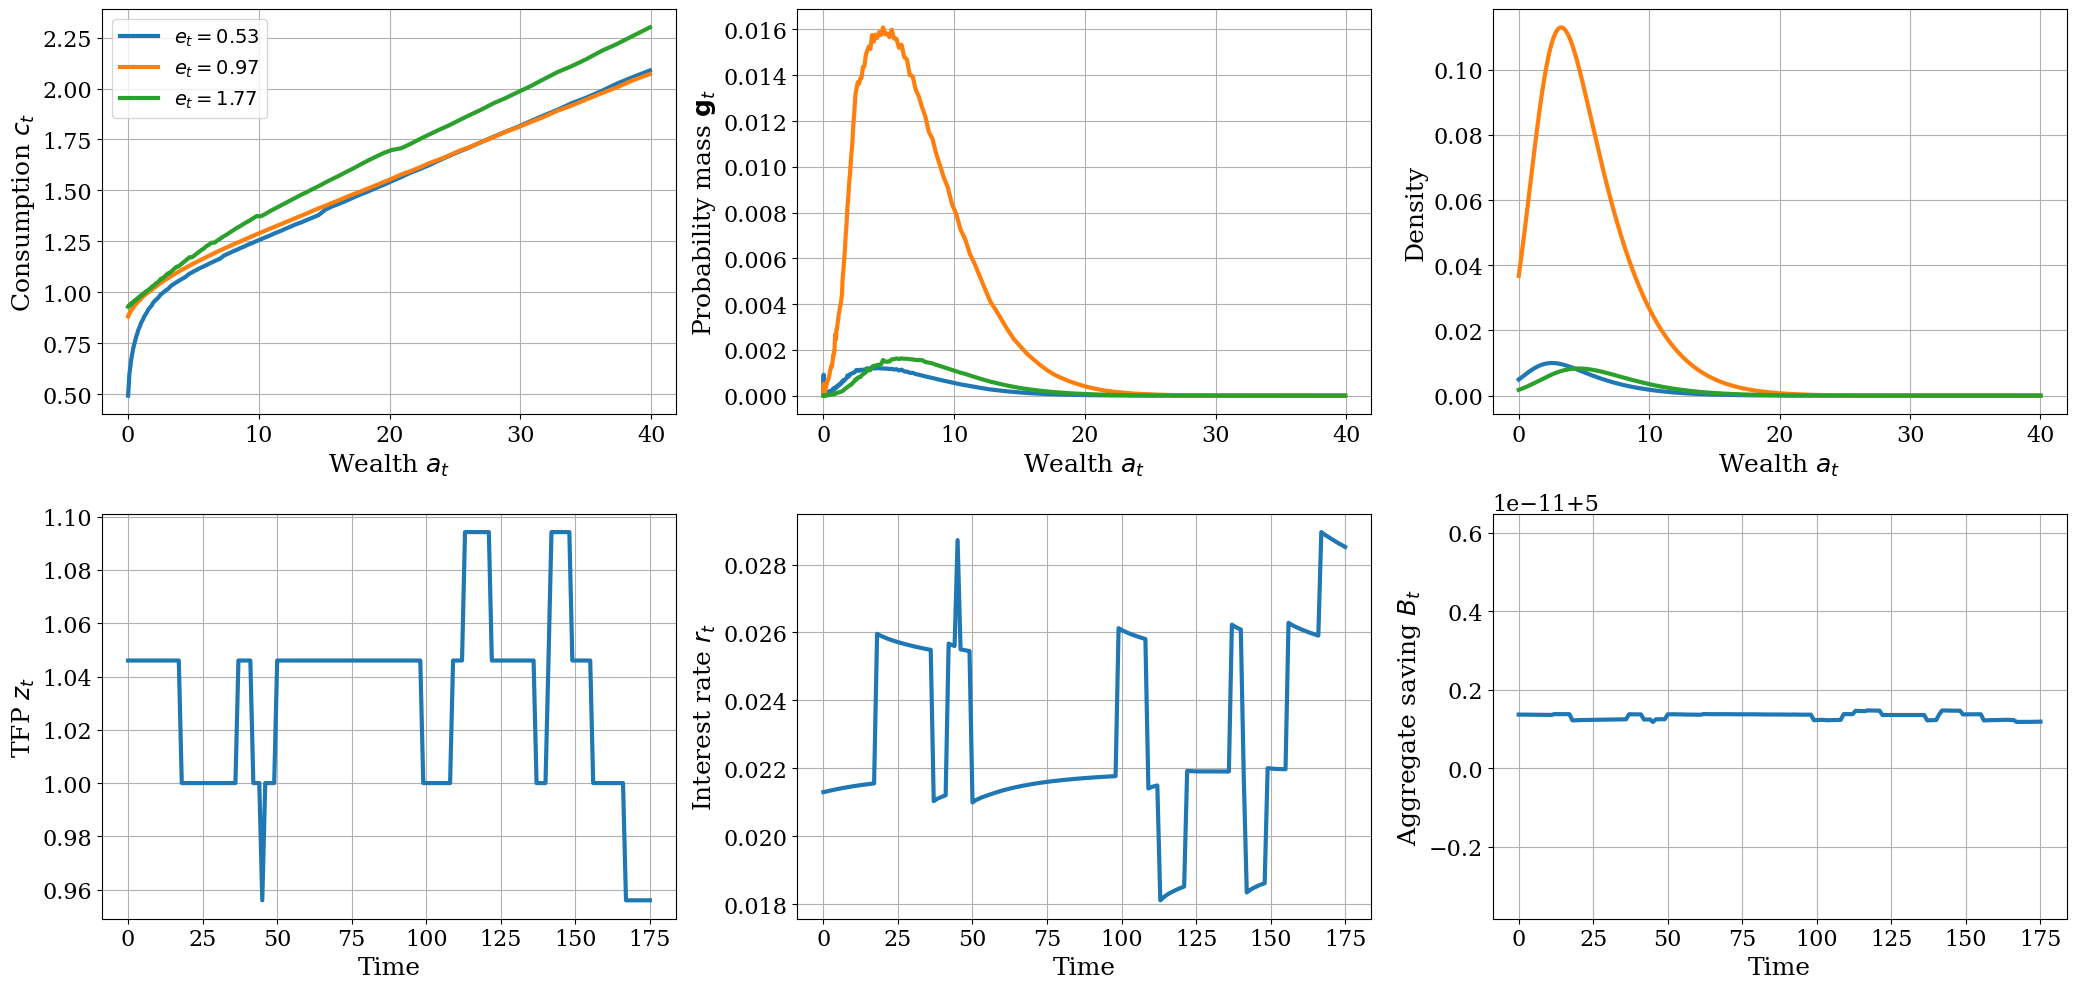

In [38]:
fig,axs = create_subplots(2,3)
# Figure 1: Comsumption policy at final period
ax = axs[0][0]
zt = 1.0
max_plot_a = 40
traj_idx = 3
idxx = jnp.where(a_grid<=max_plot_a)[0]
idxy = jnp.where(z[:,traj_idx]==zt)[0][10]
for eidx in range(ne):
    ax.plot(a_grid[idxx],c[idxy,traj_idx,idxx,eidx], label=f"$e_t={e_grid[eidx]:.2f}$")
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Consumption $c_t$")
ax.legend()
ax.grid(True)
# Figure 2: Stationary wealth distribution
ax = axs[0][1]
for eidx in range(ne):
    # plot original points
    ax.plot(a_grid[idxx], final_g[traj_idx,idxx,eidx], label=f'ORG: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Probability mass $\mathbf{g}_t$")
#ax.legend()
ax.grid(True)
# Figure 3: KDE estimate of stationary wealth distribution
ax = axs[0][2]
for eidx in range(ne):
    kde = gaussian_kde(a_grid[idxx], weights=final_g[traj_idx,idxx,eidx])
    x_smooth = np.linspace(a_min, max_plot_a, 1000)
    y_smooth = kde(x_smooth) * final_g[traj_idx,:,eidx].sum()
    ax.plot(x_smooth, y_smooth, label=f'KDE: $e_t={e_grid[eidx]:.2f}$')
ax.set_xlabel("Wealth $a_t$")
ax.set_ylabel("Density")
#ax.legend()
ax.grid(True)

# Figure 4: Time series of TFP
ax = axs[1][0]
ax.plot(z[5:,traj_idx])
ax.set_xlabel("Time")
ax.set_ylabel("TFP $z_t$")
ax.grid(True)
# Figure 5: Time series of interest rates
ax = axs[1][1]
ax.plot( r[5:,traj_idx])
ax.set_xlabel("Time")
ax.set_ylabel("Interest rate $r_t$")
ax.grid(True)
# Figure 6: Time series of aggregate assets
ax = axs[1][2]
ax.plot(b[5:,traj_idx])
ax.set_xlabel("Time")
ax.set_ylabel("Aggregate saving $B_t$")
ax.grid(True)

fig.tight_layout()
fig.savefig("./figures_tables/dynamic_model_results.pdf")